In [1]:
# cnn 이미지 분류 실습

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, auc
import joblib                                   # 파이썬 객체 저장을 위한 joblib
import tensorflow as tf

# 케라스의 모델 저장 및 로드 기능을 사용하기 위한 필요 모듈
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten       
from tensorflow.keras.callbacks import EarlyStopping    
from tensorflow.keras.utils import to_categorical

np.random.seed(42)
tf.random.set_seed(42)

In [15]:
# 데이터 가져오기
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# 클래스 이름 정의
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

print('X_train shape : ', X_train.shape)
print('X_test shape : ', X_test.shape)





X_train shape :  (60000, 28, 28)
X_test shape :  (10000, 28, 28)


In [16]:
# 데이터 정규화

# 픽셀값 0~1 범위로 정규화
X_train = X_train / 255.0
X_test = X_test / 255.0

# cnn 입력 형태에 맞게 채널 차원을 reshape
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [17]:
# 모델 정의

model = Sequential()   # 순차형 신경망 생성

# 첫 번째 합성곱(convolution layer) 층을 추가
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
# 풀링층 추가
model.add(MaxPooling2D((2,2,)))

# 두 번째 합성곱(convolution layer) 층을 추가
model.add(Conv2D(64, (3,3), activation='relu'))
# 풀링층 추가
model.add(MaxPooling2D((2,2,)))

# 1차원 벡터로 펼침
model.add(Flatten())
# 완전 연결층 추가
model.add(Dense(128, activation='relu'))
# dropout 추가
model.add(Dropout(0.3))

# 출력층 추가
model.add(Dense(10, activation='softmax'))

model.summary()



D:\anaconda3\envs\youn\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)                    │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# 모델 컴파일
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)




In [19]:
# 모델 학습
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.7840 - loss: 0.5843 - val_accuracy: 0.8592 - val_loss: 0.3943
Epoch 2/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step - accuracy: 0.8623 - loss: 0.3815 - val_accuracy: 0.8802 - val_loss: 0.3286
Epoch 3/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - accuracy: 0.8816 - loss: 0.3297 - val_accuracy: 0.8872 - val_loss: 0.3036
Epoch 4/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - accuracy: 0.8916 - loss: 0.2940 - val_accuracy: 0.8953 - val_loss: 0.2808
Epoch 5/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 24s 32ms/step - accuracy: 0.9015 - loss: 0.2693 - val_accuracy: 0.8997 - val_loss: 0.2705
Epoch 6/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 26s 34ms/step - accuracy: 0.9084 - loss: 0.2514 - val_accuracy: 0.9041 - val_loss: 0.2626
Epoch 7/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 26s 34ms/step - accuracy: 0.9141 - loss: 0.2326 - val_accuracy: 0.9063 - val_loss: 0.2576
Epoch 8/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 27s 36ms/step - accuracy: 0.9196 - loss: 0.2174 - 

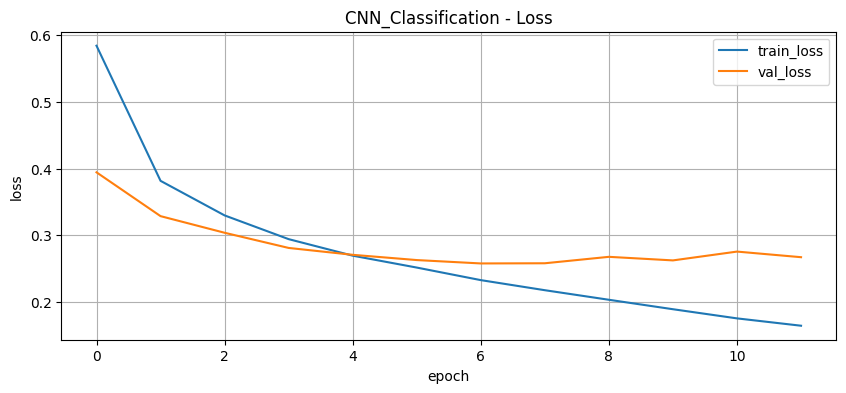

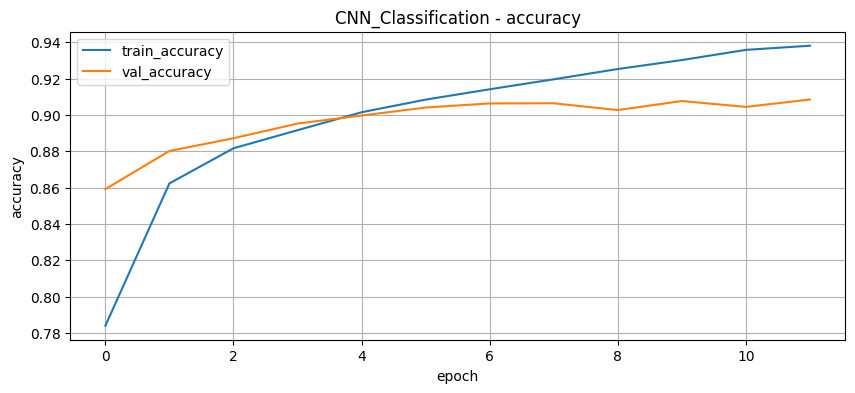

In [20]:
# 결과 시각화
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('CNN_Classification - Loss')
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('CNN_Classification - accuracy')
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [21]:
# 모델 성능 평가
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print("테스트 손실", test_loss)
print("테스트 정확도", test_acc)

테스트 손실 0.27376702427864075
테스트 정확도 0.8967999815940857


In [22]:
# 예측 확률 계산

# 테스트 데이터 예측 확률 계산
y_prob = model.predict(X_test)

# 최종 예측 클래스 계산
y_pred = np.argmax(y_prob, axis=1)




313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [23]:
# 학습 결과 저장

# 저장
model.save('./results/cnn_fashion_mnist.h5')

# 읽어오기
loaded_model = tf.keras.models.load_model('./results/cnn_fashion_mnist.h5')

In [24]:
# 신규 데이터 예측/분류
new_images = X_test[:5]

# 신규 이미지 예측
new_prob = loaded_model.predict(new_images)

# 최종 클래스 예측값 계산
new_pred = np.argmax(new_prob, axis=1)

# 예측결과 출력
for i in range(len(new_images)):
    print(f"{i+1}번 이미지 - 예측클래스: {new_pred[i]}({class_names[new_pred[i]]})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1번 이미지 - 예측클래스: 9(Ankle boot)
2번 이미지 - 예측클래스: 2(Pullover)
3번 이미지 - 예측클래스: 1(Trouser)
4번 이미지 - 예측클래스: 1(Trouser)
5번 이미지 - 예측클래스: 6(Shirt)


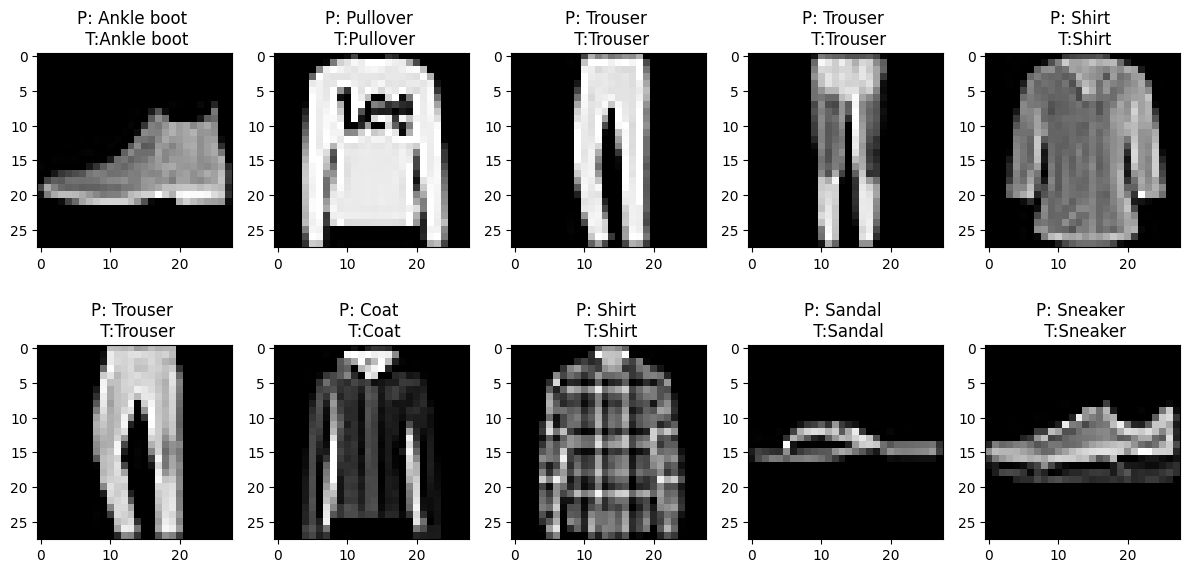

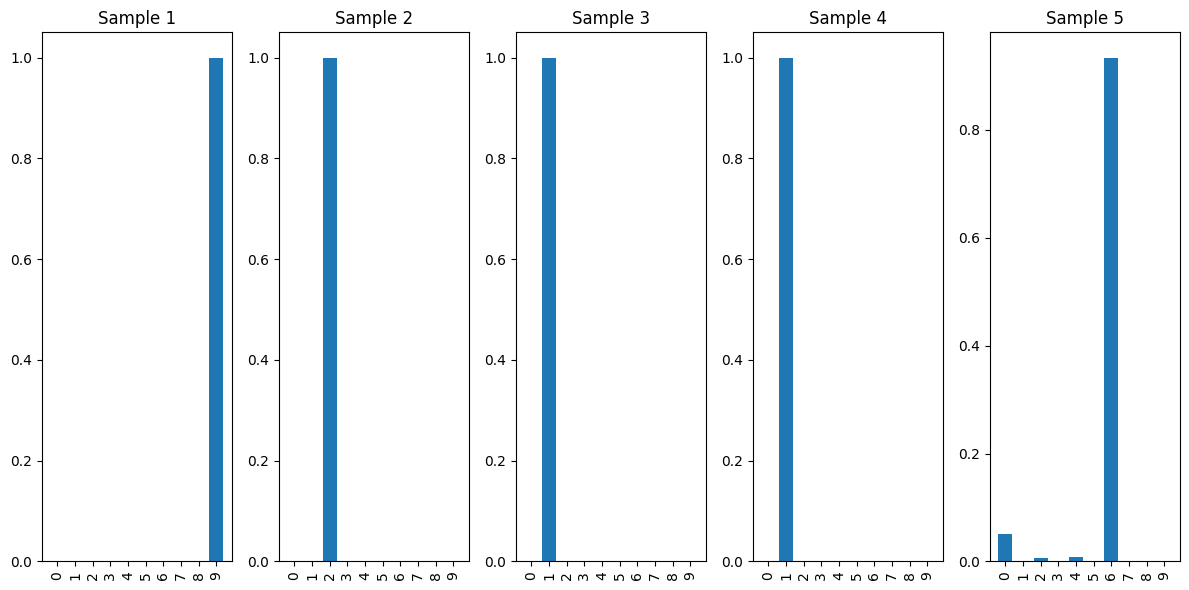

In [25]:
# 예측 결과 시각화 --> 테스트 이미지 10개와 예측 결과 시각화
plt.figure(figsize=(12, 6))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title(f"P: {class_names[y_pred[i]]} \n T:{class_names[y_test[i]]}")

plt.tight_layout()
plt.show()

# 신규 이미지 5개에 대한 확률 분포
plt.figure(figsize=(12,6))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.bar(range(10), new_prob[i])
    plt.title(f"Sample {i+1}")
    plt.xticks(range(10), rotation=90)

plt.tight_layout()
plt.show()







    